<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Numerical_Programming/svd_image_compression_bobrivets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: SVD-стиснення зображень

**Курс:** Numerical Programming in Python  
**Тема:** Матричні розклади та декомпозиції в лінійній алгебрі

У цьому ноутбуці використовується SVD/TruncatedSVD для стиснення зображень. Ми порівняємо різні значення `k`, побудуємо графік сингулярних значень, порахуємо MSE та візуально оцінимо якість реконструкції.

## 1. Імпорт бібліотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_sample_images

plt.rcParams['figure.figsize'] = (8, 5)

## 2. Підготовка зображень

Для експерименту використаємо два стандартні RGB-зображення зі `sklearn`. Щоб виконати вимогу завдання, спочатку збережемо їх як `.jpg`, а потім зчитаємо назад за допомогою `imread` з бібліотеки `matplotlib`.

0: image_1.jpg, shape=(427, 640, 3), dtype=uint8
1: image_2.jpg, shape=(427, 640, 3), dtype=uint8


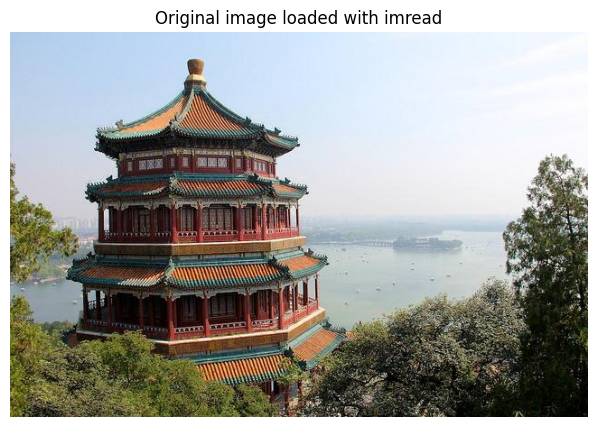

In [2]:
sample_images = load_sample_images()
images_raw = sample_images.images
image_names = sample_images.filenames


plt.imsave("image_1.jpg", images_raw[0])
plt.imsave("image_2.jpg", images_raw[1])

image_1 = imread("image_1.jpg")
image_2 = imread("image_2.jpg")

def to_uint8(img):
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    return img

image_1 = to_uint8(image_1)
image_2 = to_uint8(image_2)

images = [image_1, image_2]
image_names = ["image_1.jpg", "image_2.jpg"]

for i, img in enumerate(images):
    print(f'{i}: {image_names[i]}, shape={img.shape}, dtype={img.dtype}')

image = images[0]

plt.imshow(image)
plt.axis('off')
plt.title('Original image loaded with imread')
plt.show()


### Альтернатива: завантаження власного зображення

Якщо хочете використати власний файл, розкоментуйте код нижче та завантажте `.jpg`/`.png` у Colab.

In [3]:
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# image = imread(filename)
# if image.dtype != np.uint8:
#     image = (image * 255).astype(np.uint8)
# plt.imshow(image)
# plt.axis('off')
# plt.title('Uploaded image')
# plt.show()

## 3. Розмір зображення

In [4]:
print('Image shape:', image.shape)
height, width, channels = image.shape
print('Height:', height)
print('Width:', width)
print('Channels:', channels)

Image shape: (427, 640, 3)
Height: 427
Width: 640
Channels: 3


## 4. Перетворення 3D-зображення у 2D-матрицю

SVD працює з 2D-матрицею. RGB-зображення має форму `(height, width, channels)`, тому перетворимо його у 2D-матрицю, об'єднавши канали горизонтально.

In [5]:
flat_image = image.reshape(-1, width * channels)
print('Flat image shape:', flat_image.shape)

Flat image shape: (427, 1920)


## 5. SVD-декомпозиція та візуалізація сингулярних значень

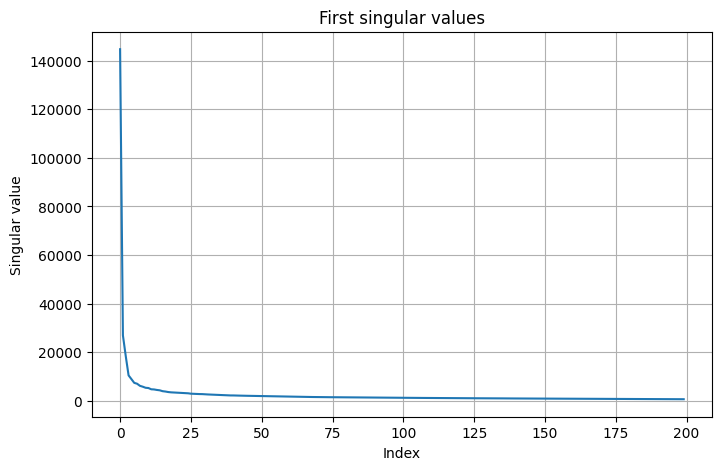

In [6]:
U, S, Vt = np.linalg.svd(flat_image.astype(float), full_matrices=False)

k_plot = min(200, len(S))
plt.plot(np.arange(k_plot), S[:k_plot])
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.title('First singular values')
plt.grid(True)
plt.show()

На графіку видно, що перші сингулярні значення значно більші за наступні. Це означає, що велика частина інформації зображення зосереджена у невеликій кількості компонент, тому SVD можна використати для стиснення.

## 6. Функція для стиснення та реконструкції зображення

In [7]:
def compress_image_with_svd(image, k):
    height, width, channels = image.shape
    flat_image = image.reshape(-1, width * channels).astype(float)

    svd = TruncatedSVD(n_components=k, random_state=42)
    compressed = svd.fit_transform(flat_image)
    reconstructed_flat = svd.inverse_transform(compressed)

    mse = np.mean(np.square(reconstructed_flat - flat_image))
    explained_variance = svd.explained_variance_ratio_.sum()

    reconstructed = reconstructed_flat.reshape(height, width, channels)
    reconstructed = np.clip(reconstructed, 0, 255).astype('uint8')

    return reconstructed, mse, explained_variance

## 7. Експерименти з різними значеннями k

In [8]:
k_values = [5, 10, 25, 50, 100, 200]
results = []

for k in k_values:
    reconstructed, mse, explained_variance = compress_image_with_svd(image, k)
    results.append({
        'k': k,
        'mse': mse,
        'explained_variance': explained_variance,
        'image': reconstructed
    })
    print(f'k={k:3d} | MSE={mse:.2f} | Explained variance={explained_variance:.4f}')

k=  5 | MSE=1057.69 | Explained variance=0.8312
k= 10 | MSE=801.96 | Explained variance=0.8720
k= 25 | MSE=510.28 | Explained variance=0.9185
k= 50 | MSE=324.76 | Explained variance=0.9481
k=100 | MSE=167.13 | Explained variance=0.9733
k=200 | MSE=41.17 | Explained variance=0.9934


## 8. Візуалізація результатів реконструкції

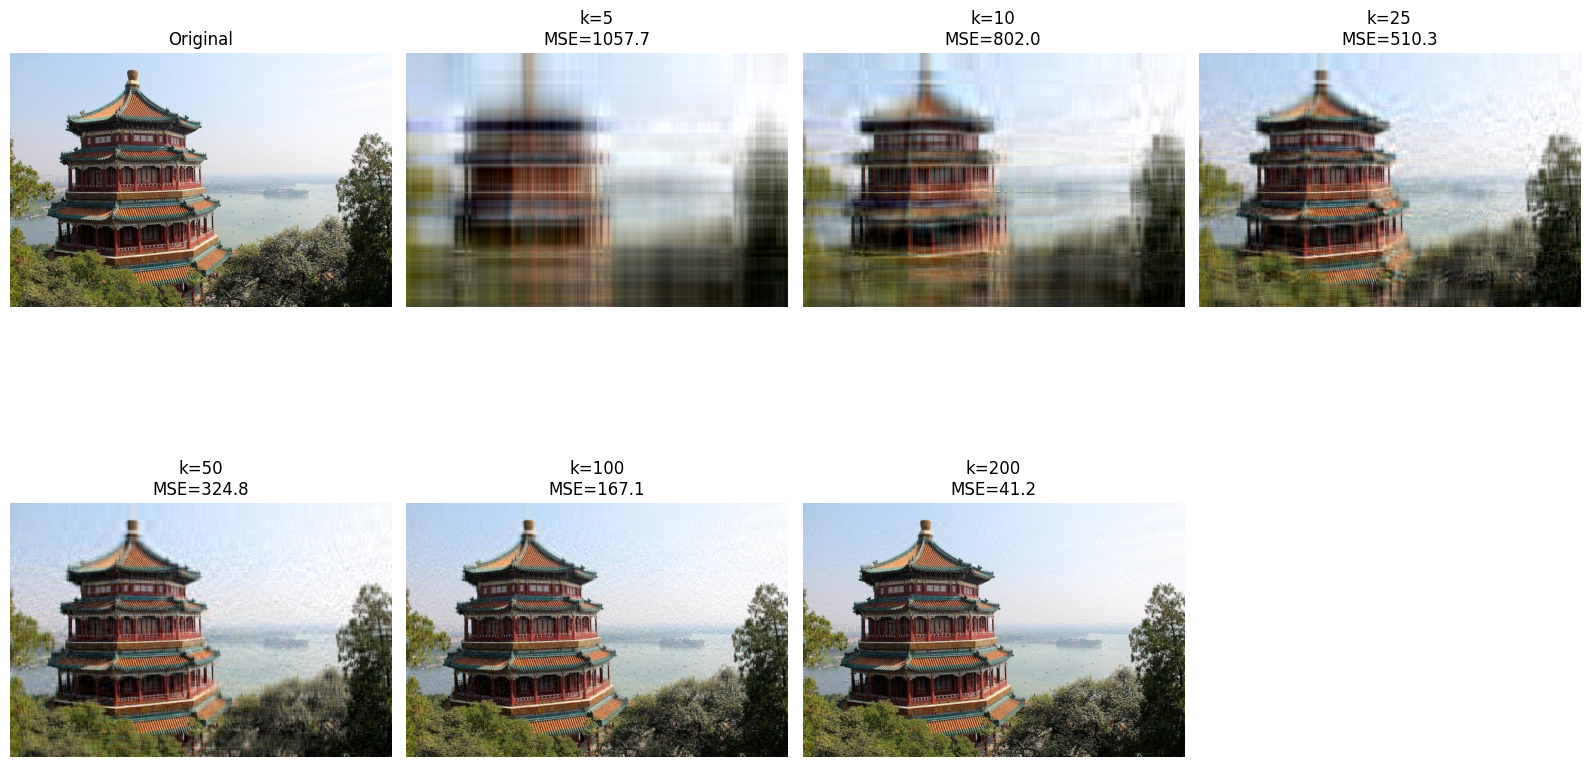

In [9]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 4, 1)
plt.imshow(image)
plt.axis('off')
plt.title('Original')

for i, result in enumerate(results, start=2):
    plt.subplot(2, 4, i)
    plt.imshow(result['image'])
    plt.axis('off')
    plt.title(f"k={result['k']}\nMSE={result['mse']:.1f}")

plt.tight_layout()
plt.show()

## 9. Графік залежності MSE та explained variance від k

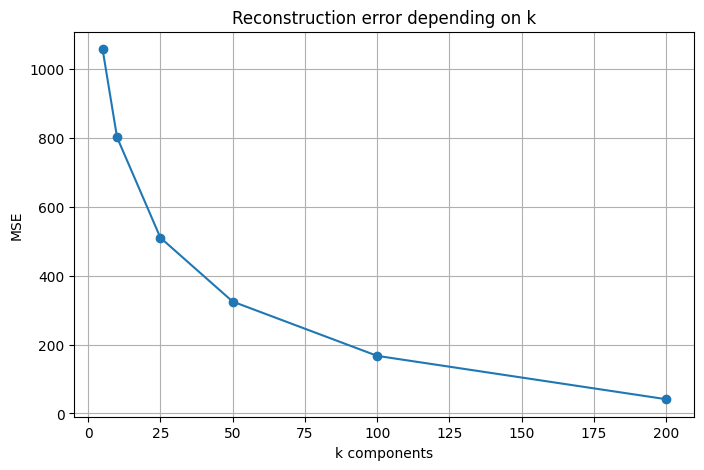

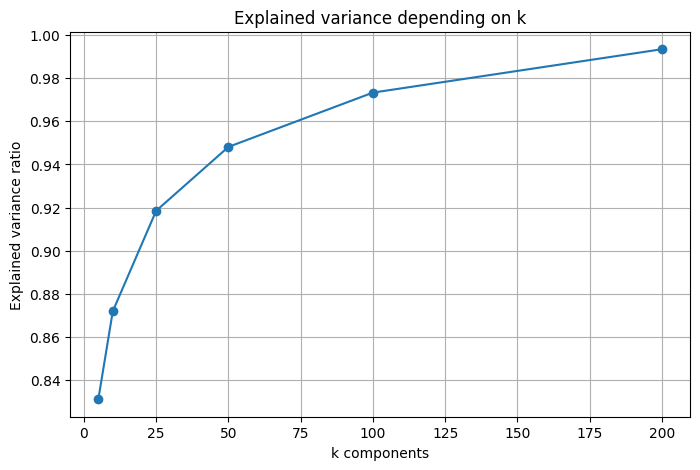

In [10]:
mse_values = [r['mse'] for r in results]
explained_values = [r['explained_variance'] for r in results]

plt.plot(k_values, mse_values, marker='o')
plt.xlabel('k components')
plt.ylabel('MSE')
plt.title('Reconstruction error depending on k')
plt.grid(True)
plt.show()

plt.plot(k_values, explained_values, marker='o')
plt.xlabel('k components')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance depending on k')
plt.grid(True)
plt.show()

## 10. Додатковий експеримент із другим зображенням

Second image shape: (427, 640, 3)
k= 10 | MSE=242.86 | Explained variance=0.8875
k= 50 | MSE=39.19 | Explained variance=0.9818
k=100 | MSE=8.77 | Explained variance=0.9959
k=200 | MSE=0.58 | Explained variance=0.9997


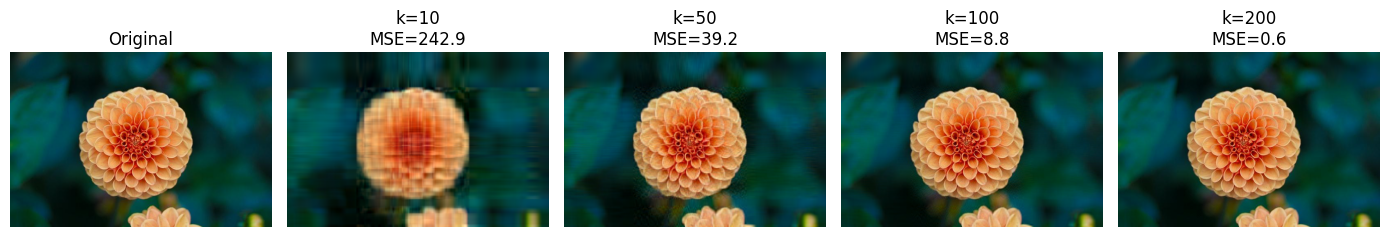

In [11]:
image2 = images[1]
print('Second image shape:', image2.shape)

k_values_2 = [10, 50, 100, 200]
results_2 = []

for k in k_values_2:
    reconstructed, mse, explained_variance = compress_image_with_svd(image2, k)
    results_2.append((k, reconstructed, mse, explained_variance))
    print(f'k={k:3d} | MSE={mse:.2f} | Explained variance={explained_variance:.4f}')

plt.figure(figsize=(14, 7))
plt.subplot(1, len(k_values_2) + 1, 1)
plt.imshow(image2)
plt.axis('off')
plt.title('Original')

for i, (k, reconstructed, mse, _) in enumerate(results_2, start=2):
    plt.subplot(1, len(k_values_2) + 1, i)
    plt.imshow(reconstructed)
    plt.axis('off')
    plt.title(f'k={k}\nMSE={mse:.1f}')

plt.tight_layout()
plt.show()

## Висновки

1. SVD дозволяє представити зображення через набір сингулярних значень і відповідних компонент.
2. Перші сингулярні значення мають найбільший внесок у збереження структури зображення. На графіку видно швидке спадання значень, тому зображення можна стискати.
3. При малих значеннях `k`, наприклад `k=5` або `k=10`, якість зображення помітно погіршується: зникають деталі, зображення стає розмитим.
4. При середніх значеннях `k`, наприклад `k=50` або `k=100`, основні контури та кольори вже добре зберігаються, а MSE значно зменшується.
5. При великих значеннях `k`, наприклад `k=200`, реконструйоване зображення стає дуже схожим на оригінальне, але ступінь стиснення зменшується.
6. Отже, вибір `k` є компромісом між якістю реконструкції та ступенем стиснення. Для обраного зображення помітна втрата якості спостерігається при малих `k`, а прийнятна якість досягається приблизно з `k=50–100`.